## IMPORT

In [37]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [39]:
from sklearn.metrics import roc_auc_score

In [40]:
## Na macos
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(torch.backends.mps.is_available())   # True
print(torch.backends.mps.is_built())       # True

True
True


## DANE

In [41]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## MODEL I TRENING

In [42]:
from sklearn.metrics import accuracy_score

In [43]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model.predict(images)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return accuracy_score(all_labels, all_preds)

### MLP z regresja logistyczna

In [44]:
class MLP(nn.Module):
    def __init__(self, input_size: int, num_classes: int = 10, dropout_p: float = 0.2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, num_classes),  # 10 klas
        )

    def forward(self, x):
        return self.layers(x)

    def predict_proba(self, x):
        return torch.softmax(self(x), dim=1)  # (N, 10) — prawdopodobieństwa dla każdej klasy

    def predict(self, x):
        return torch.argmax(self.predict_proba(x), dim=1)  # klasa z najwyższym prawdopodobieństwem

### CNN

In [45]:
class CNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.layers = nn.Sequential(
            # blok 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 32x32 → 16x16
            nn.Dropout(p=0.2),

            # blok 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # 16x16 → 8x8
            nn.Dropout(p=0.2),

            # klasyfikator
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.layers(x)

    def predict_proba(self, x):
        return torch.softmax(self(x), dim=1)

    def predict(self, x):
        return torch.argmax(self.predict_proba(x), dim=1)

In [35]:
configs = [
    {
        "name": "MLP",
        "model": MLP(input_size=3*32*32),
        "lr": 1e-3,
        "loss_fn": nn.CrossEntropyLoss(),
    },
    {
        "name": "CNN",
        "model": CNN(),
        "lr": 1e-3,
        "loss_fn": nn.CrossEntropyLoss(),
    },
]

def train(model, optimizer, loss_fn, num_epochs=20):
    model = model.to(device)
    train_accs, test_accs, losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_acc = evaluate(model, trainloader)
        test_acc = evaluate(model, testloader)
        print(f"Epoch {epoch+1} loss: {running_loss/len(trainloader):.4f} | train acc: {train_acc:.2%} | test acc: {test_acc:.2%}")

        train_accs.append(train_acc)
        test_accs.append(test_acc)
        losses.append(running_loss / len(trainloader))

    return train_accs, test_accs, losses, model

In [46]:
results = {}
for config in configs:
    print(f"\n=== {config['name']} ===")
    model = config["model"]
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    results[config["name"]] = train(model, optimizer, config["loss_fn"])


=== MLP ===
Epoch 1 loss: 1.5525 | train acc: 51.44% | test acc: 47.92%
Epoch 2 loss: 1.4733 | train acc: 52.30% | test acc: 48.54%
Epoch 3 loss: 1.4152 | train acc: 55.92% | test acc: 50.99%
Epoch 4 loss: 1.3633 | train acc: 57.69% | test acc: 51.14%
Epoch 5 loss: 1.3180 | train acc: 59.16% | test acc: 51.39%
Epoch 6 loss: 1.2852 | train acc: 60.38% | test acc: 51.38%
Epoch 7 loss: 1.2442 | train acc: 62.87% | test acc: 53.04%
Epoch 8 loss: 1.2118 | train acc: 63.63% | test acc: 52.79%
Epoch 9 loss: 1.1858 | train acc: 64.80% | test acc: 53.50%
Epoch 10 loss: 1.1493 | train acc: 66.05% | test acc: 52.92%
Epoch 11 loss: 1.1260 | train acc: 67.05% | test acc: 53.46%
Epoch 12 loss: 1.1010 | train acc: 68.27% | test acc: 54.08%
Epoch 13 loss: 1.0743 | train acc: 70.25% | test acc: 54.38%
Epoch 14 loss: 1.0536 | train acc: 70.02% | test acc: 53.75%
Epoch 15 loss: 1.0354 | train acc: 71.21% | test acc: 54.09%
Epoch 16 loss: 1.0094 | train acc: 72.06% | test acc: 54.06%
Epoch 17 loss: 0.997

In [47]:
for name, (train_accs, test_accs, losses, model) in results.items():
    torch.save(model.state_dict(), f"{name}_cifar10.pth")

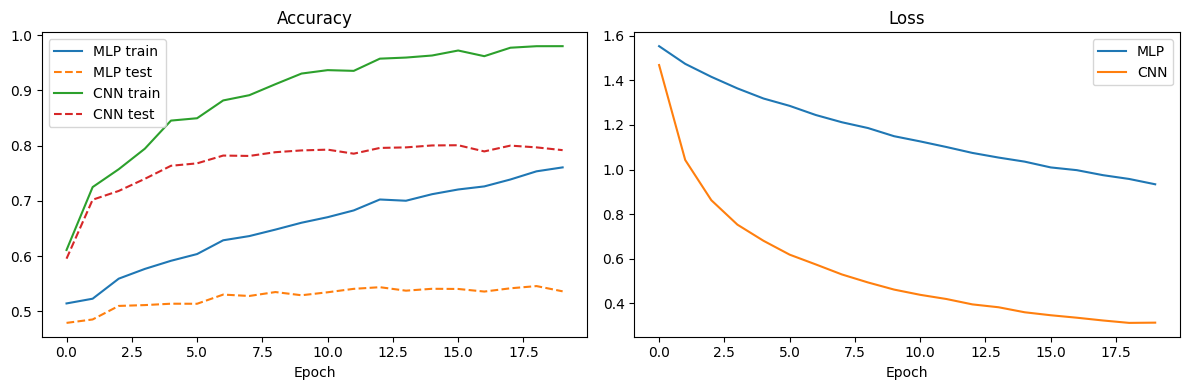

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, (train_accs, test_accs, losses, model) in results.items():
    ax1.plot(train_accs, label=f'{name} train')
    ax1.plot(test_accs, label=f'{name} test', linestyle='--')
    ax2.plot(losses, label=name)

ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.show()

In [49]:
def evaluate_full(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            probs = model.predict_proba(images)
            preds = model.predict(images)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_labels)
    )

for name, (train_accs, test_accs, losses, model) in results.items():
    y_probs, y_preds, y_true = evaluate_full(model, testloader)
    acc = accuracy_score(y_true, y_preds)
    auroc = roc_auc_score(y_true, y_probs, multi_class='ovr')
    print(f"{name} | Accuracy: {acc:.2%} | AUROC: {auroc:.2%}")

MLP | Accuracy: 53.63% | AUROC: 89.44%
CNN | Accuracy: 79.18% | AUROC: 97.63%
